# ROC Comparison: fm4tag vs Reference Taggers

Compares jet-flavour tagging performance (b-jet efficiency vs background rejection) between:
- **fm4tag** model trained with this framework (loaded from a Lightning checkpoint)
- **Reference taggers** whose scores are stored in HDF5 output files (GN2v01, DL1d, GN2 Open Data, GN2 only-JT, …)

The reference tagger files are read with `ftag.hdf5.H5Reader` + kinematic cuts; fm4tag
is run directly with the fm4tag DataLoader + a reconstructed Lightning module.

**Discriminant** used for both fm4tag and GN2-style reference taggers:
$$D_b = \log\frac{p_b}{f_c\,p_c + f_\tau\,p_\tau + (1-f_c-f_\tau)\,p_u}$$
with default $f_c = 0.2$, $f_\tau = 0.01$.

In [1]:
import numpy as np
import pandas as pd
import h5py
import torch
from torch.utils.data import DataLoader
from omegaconf import OmegaConf
from tqdm import tqdm

from ftag.hdf5 import H5Reader
from ftag.cuts import Cuts
from ftag.utils import calculate_rejection
from puma import Roc, RocPlot

import matplotlib.pyplot as plt

%matplotlib inline

# fm4tag package imports
from fm4tag.engine import _build_encoders
from fm4tag.models.components.heads import MultiStreamClassifierHead
from fm4tag.models.finetune_module import FinetuneModule
from fm4tag.data.datasets import DatasetCatCon, cat_con_collate_fn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## Configuration

Edit the paths below to point to your files.

- `FM4TAG_CONFIG` — `config.yaml` saved alongside the fm4tag checkpoint (in `outputs/.../version_N/config.yaml`)
- `FM4TAG_CKPT` — Lightning `.ckpt` file to evaluate
- `FM4TAG_TEST_FILE` — HDF5 test file to run fm4tag inference on (can override `cfg.test_file`)
- Reference tagger files: HDF5 files that contain the salt/GN2 output scores

In [2]:
# ── fm4tag model ──────────────────────────────────────────────────────────────
FM4TAG_CONFIG = '/storage3/DSIP/rriva/research/fm4tag/slurm/classify_from_scratch/run_20260303_173528/outputs/2026-03-03/17-37-31/.hydra/config.yaml'  # e.g. 'outputs/model_0_col/version_0/config.yaml'
FM4TAG_CKPT = '/storage3/DSIP/rriva/research/fm4tag/slurm/classify_from_scratch/run_20260303_173528/outputs/model_0_colrow/version_0/checkpoints/epoch=021-val_loss=0.6141.ckpt'  # e.g. 'outputs/model_0_col/version_0/checkpoints/epoch=049-val_loss=0.5000.ckpt'
FM4TAG_TEST_FILE = '/storage3/DSIP/rriva/datasets/transforming-jet-flavor/data_parallel_preprocess_251112_152051/test/output/pp_output_test.h5'  # None → use cfg.test_file from the saved config

FM4TAG_LABEL = 'fm4tag'  # label shown in the ROC plot legend

# ── Reference tagger HDF5 files ──────────────────────────────────────────────
# File that contains GN2v01, DL1dv01, and GN2-open-data scores on the same jets
SALT_FNAME = '/storage3/DSIP/rriva/packages/salt-pt/salt/logs/GN2_20251202-T162204/ckpts/epoch=025-val_loss=0.60416__test_pp_output_test.h5'
# File with GN2-only-JT scores
SALT_JT_FNAME = '/storage3/DSIP/rriva/packages/salt-pt/salt/logs/GN2_only_jt_20251208-T171609/ckpts/epoch=012-val_loss=0.61484__test_pp_output_test.h5'

# ── Jet kinematic cuts (applied to reference taggers and fm4tag) ──────────────
CUTS = Cuts.from_list(
    [
        ('pt', '>', 20_000),
        ('pt', '<', 250_000),
        ('eta', '<', 2.5),
        ('eta', '>', -2.5),
    ]
)

SIG_EFF = np.linspace(0.6, 1, 100)  # b-jet efficiency working points

# ── Discriminant fractions ────────────────────────────────────────────────────
F_C = 0.2  # c-jet fraction
F_TAU = 0.01  # tau-jet fraction

## Discriminant functions

Vectorized implementations operating on full `(N, k)` arrays — avoid per-row Python calls.

In [3]:
def disc_gn2_vec(arr: np.ndarray, f_c: float = F_C, f_tau: float = F_TAU) -> np.ndarray:
    """GN2-style discriminant (vectorized).
    arr shape: (N, 4) with columns [pb, pc, pu, ptau].
    Returns shape (N,). Produces -inf where pb=0, +inf where denom=0.
    """
    with np.errstate(divide='ignore', invalid='ignore'):
        denom = f_c * arr[:, 1] + f_tau * arr[:, 3] + (1 - f_c - f_tau) * arr[:, 2]
        return np.log(arr[:, 0] / denom)


def disc_dl1d_vec(arr: np.ndarray, f_c: float = 0.018) -> np.ndarray:
    """DL1d-style discriminant (vectorized).
    arr shape: (N, 3) with columns [pb, pc, pu].
    Returns shape (N,).
    """
    with np.errstate(divide='ignore', invalid='ignore'):
        return np.log(arr[:, 0] / (f_c * arr[:, 1] + (1 - f_c) * arr[:, 2]))

## Load reference taggers from HDF5

In [4]:
jet_vars = [
    'pt',
    'eta',
    'HadronConeExclTruthLabelID',
    'DL1dv01_pu',
    'DL1dv01_pc',
    'DL1dv01_pb',
    'GN2v01_ptau',
    'GN2v01_pu',
    'GN2v01_pc',
    'GN2v01_pb',
    'GN2_ptau',
    'GN2_pu',
    'GN2_pc',
    'GN2_pb',
]
jet_vars_jt = [
    'pt',
    'eta',
    'HadronConeExclTruthLabelID',
    'GN2_only_jt_ptau',
    'GN2_only_jt_pu',
    'GN2_only_jt_pc',
    'GN2_only_jt_pb',
]

reader = H5Reader(fname=SALT_FNAME, jets_name='jets', batch_size=10_000)
reader_jt = H5Reader(fname=SALT_JT_FNAME, jets_name='jets', batch_size=10_000)

df = pd.DataFrame(reader.load(variables={'jets': jet_vars}, cuts=CUTS)['jets'])
df_jt = pd.DataFrame(reader_jt.load(variables={'jets': jet_vars_jt}, cuts=CUTS)['jets'])

print(f'Reference (salt)  jets: {len(df):,}')
print(f'Reference (JT)    jets: {len(df_jt):,}')

Reference (salt)  jets: 1,859,663
Reference (JT)    jets: 1,859,663


## Load fm4tag model and run inference

In [5]:
assert FM4TAG_CONFIG is not None, (
    'Set FM4TAG_CONFIG to the path of your run config.yaml'
)
assert FM4TAG_CKPT is not None, 'Set FM4TAG_CKPT to the path of your .ckpt file'

cfg = OmegaConf.load(FM4TAG_CONFIG)

# ── Build encoders (mirrors engine._build_encoders) ──────────────────────────
encoders = _build_encoders(cfg)

# ── Build classifier head (mirrors engine.run finetune branch) ────────────────
head_cfg = cfg.head
n_classes = len(cfg.variables[cfg.global_object].unique_labels)
n_global_features = len(cfg.variables[cfg.global_object].inputs)
n_constituent_features = [
    len(cfg.variables[obj].inputs.continuous)
    + len(cfg.variables[obj].inputs.categorical)
    for obj in cfg.constituent_objects
]
head = MultiStreamClassifierHead(
    dim=cfg.encoder.dim,
    n_global_features=n_global_features,
    n_constituent_features=n_constituent_features,
    y_dim=n_classes,
    cls_dim=head_cfg.get('cls_dim', None),
    mlp_dropout=head_cfg.get('mlp_dropout', 0.0),
    ff_dropout=head_cfg.get('ff_dropout', 0.0),
    attn_dropout=head_cfg.get('attn_dropout', 0.0),
    ff_mult=head_cfg.get('ff_mult', 4),
    heads=head_cfg.get('heads', 8),
    dim_head=head_cfg.get('dim_head', 16),
    depth=head_cfg.get('depth', 3),
)

module = FinetuneModule(encoders, head, cfg)

# ── Load checkpoint weights ───────────────────────────────────────────────────
ckpt = torch.load(FM4TAG_CKPT, map_location='cpu', weights_only=False)
module.on_load_checkpoint(ckpt)  # handles backwards-compat key renames
module.load_state_dict(ckpt['state_dict'])
module.eval()
module.to(device)
print('Model loaded and moved to', device)

Model loaded and moved to cuda


In [6]:
# Resolve test file (config value or explicit override)
_test_file = FM4TAG_TEST_FILE or cfg.get('test_file')
assert _test_file is not None, 'Set FM4TAG_TEST_FILE or ensure cfg.test_file is set'

norm_dict = (
    OmegaConf.to_container(OmegaConf.load(cfg.norm_dict), resolve=True)
    if cfg.get('norm_dict')
    else None
)
class_dict = (
    OmegaConf.to_container(OmegaConf.load(cfg.class_dict), resolve=True)
    if cfg.get('class_dict')
    else None
)

dataset = DatasetCatCon(
    file_path=_test_file,
    variables=cfg.variables,
    global_object=cfg.global_object,
    constituent_objects=list(cfg.constituent_objects),
    norm_dict=norm_dict,
    class_dict=class_dict,
)
_num_workers = 4
loader = DataLoader(
    dataset,
    batch_size=512,
    shuffle=False,
    num_workers=_num_workers,
    collate_fn=cat_con_collate_fn,
    pin_memory=True,
    prefetch_factor=2 if _num_workers > 0 else None,
)

# ── Run inference ─────────────────────────────────────────────────────────────
# torch.inference_mode() is stronger than no_grad(): also disables the version
# counter so autograd tracking overhead is fully eliminated.
probs_list = []
with torch.inference_mode():
    for batch in tqdm(loader, desc='fm4tag inference'):
        batch_dev = {
            'global': batch['global'].to(device),
            'constituents': {
                k: {kk: vv.to(device) for kk, vv in v.items()}
                for k, v in batch['constituents'].items()
            },
        }
        p = module(batch_dev).softmax(dim=-1)  # (B, n_classes)
        probs_list.append(p.cpu())

probs_fm4tag = torch.cat(probs_list, dim=0).numpy()  # (N_jets, 4): [b, c, light, tau]
print(f'fm4tag probs shape: {probs_fm4tag.shape}')


DatasetCatCon: /storage3/DSIP/rriva/datasets/transforming-jet-flavor/data_parallel_preprocess_251112_152051/test/output/pp_output_test.h5
  samples : 1860000


fm4tag inference: 100%|██████████| 3633/3633 [12:50<00:00,  4.71it/s]

fm4tag probs shape: (1860000, 4)


## Apply cuts to fm4tag predictions and define flavour masks

fm4tag uses `flavour_label` (0=b, 1=c, 2=u/light, 3=tau) internally.
For consistency with the reference taggers we also read `HadronConeExclTruthLabelID`
(5=b, 4=c, 0=light, 15=tau) and apply the same kinematic cuts.

In [7]:
with h5py.File(_test_file, 'r') as f:
    jets_pt = f['jets']['pt'][:]
    jets_eta = f['jets']['eta'][:]
    truth_id = f['jets']['HadronConeExclTruthLabelID'][:]  # 0=u, 4=c, 5=b, 15=tau

cut_mask = (jets_pt > 20_000) & (jets_pt < 250_000) & (np.abs(jets_eta) < 2.5)

probs_cut = probs_fm4tag[cut_mask]  # (N_cut, 4)
truth_cut = truth_id[cut_mask]

# Flavour boolean masks as plain numpy arrays
is_b_fm4tag = truth_cut == 5
is_c_fm4tag = truth_cut == 4
is_u_fm4tag = truth_cut == 0
is_tau_fm4tag = truth_cut == 15

n_fm4tag_b, n_fm4tag_c = int(is_b_fm4tag.sum()), int(is_c_fm4tag.sum())
n_fm4tag_u, n_fm4tag_tau = int(is_u_fm4tag.sum()), int(is_tau_fm4tag.sum())
print(
    f'fm4tag after cuts — b: {n_fm4tag_b:,}  c: {n_fm4tag_c:,}  '
    f'u: {n_fm4tag_u:,}  tau: {n_fm4tag_tau:,}  total: {cut_mask.sum():,}'
)

fm4tag after cuts — b: 479,947  c: 479,818  u: 719,901  tau: 179,997  total: 1,859,663


## Compute discriminants for all taggers

In [8]:
# fm4tag: column order is [pb, pc, pu, ptau] = [0, 1, 2, 3] — matches disc_gn2_vec expectation
discs_fm4tag = disc_gn2_vec(probs_cut)

# Reference taggers — pass columns in [pb, pc, pu, ptau] order
discs_dl1d_v01 = disc_dl1d_vec(
    df[['DL1dv01_pb', 'DL1dv01_pc', 'DL1dv01_pu']].to_numpy()
)
discs_gn2_v01 = disc_gn2_vec(
    df[['GN2v01_pb', 'GN2v01_pc', 'GN2v01_pu', 'GN2v01_ptau']].to_numpy()
)
discs_gn2_od = disc_gn2_vec(df[['GN2_pb', 'GN2_pc', 'GN2_pu', 'GN2_ptau']].to_numpy())
discs_gn2_jt = disc_gn2_vec(
    df_jt[
        ['GN2_only_jt_pb', 'GN2_only_jt_pc', 'GN2_only_jt_pu', 'GN2_only_jt_ptau']
    ].to_numpy()
)

print('Discriminant shapes:')
for name, arr in [
    (FM4TAG_LABEL, discs_fm4tag),
    ('GN2v01', discs_gn2_v01),
    ('GN2-OD', discs_gn2_od),
    ('GN2-JT', discs_gn2_jt),
    ('DL1dv01', discs_dl1d_v01),
]:
    print(f'  {name:>14}: {arr.shape}')

Discriminant shapes:
          fm4tag: (1859663,)
          GN2v01: (1859663,)
          GN2-OD: (1859663,)
          GN2-JT: (1859663,)
         DL1dv01: (1859663,)


## Compute background rejections

In [9]:
# Convert pandas boolean Series to numpy once, up front — avoids repeated overhead
# when the same masks are used for indexing numpy arrays.
_tid = df['HadronConeExclTruthLabelID'].to_numpy()
_tid_jt = df_jt['HadronConeExclTruthLabelID'].to_numpy()

is_b = _tid == 5
is_c = _tid == 4
is_u = _tid == 0
is_tau = _tid == 15
is_b_jt = _tid_jt == 5
is_c_jt = _tid_jt == 4
is_u_jt = _tid_jt == 0
is_tau_jt = _tid_jt == 15

n_ref_u, n_ref_c, n_ref_tau = int(is_u.sum()), int(is_c.sum()), int(is_tau.sum())
n_jt_u, n_jt_c, n_jt_tau = int(is_u_jt.sum()), int(is_c_jt.sum()), int(is_tau_jt.sum())

# ── fm4tag ───────────────────────────────────────────────────────────────────
fm4tag_u_rej = calculate_rejection(
    discs_fm4tag[is_b_fm4tag], discs_fm4tag[is_u_fm4tag], SIG_EFF
)
fm4tag_c_rej = calculate_rejection(
    discs_fm4tag[is_b_fm4tag], discs_fm4tag[is_c_fm4tag], SIG_EFF
)
fm4tag_tau_rej = calculate_rejection(
    discs_fm4tag[is_b_fm4tag], discs_fm4tag[is_tau_fm4tag], SIG_EFF
)

# ── GN2v01 ───────────────────────────────────────────────────────────────────
gn2v01_u_rej = calculate_rejection(discs_gn2_v01[is_b], discs_gn2_v01[is_u], SIG_EFF)
gn2v01_c_rej = calculate_rejection(discs_gn2_v01[is_b], discs_gn2_v01[is_c], SIG_EFF)
gn2v01_tau_rej = calculate_rejection(
    discs_gn2_v01[is_b], discs_gn2_v01[is_tau], SIG_EFF
)

# ── GN2 Open Data ─────────────────────────────────────────────────────────────
gn2od_u_rej = calculate_rejection(discs_gn2_od[is_b], discs_gn2_od[is_u], SIG_EFF)
gn2od_c_rej = calculate_rejection(discs_gn2_od[is_b], discs_gn2_od[is_c], SIG_EFF)
gn2od_tau_rej = calculate_rejection(discs_gn2_od[is_b], discs_gn2_od[is_tau], SIG_EFF)

# ── GN2 only-JT ──────────────────────────────────────────────────────────────
gn2jt_u_rej = calculate_rejection(discs_gn2_jt[is_b_jt], discs_gn2_jt[is_u_jt], SIG_EFF)
gn2jt_c_rej = calculate_rejection(discs_gn2_jt[is_b_jt], discs_gn2_jt[is_c_jt], SIG_EFF)
gn2jt_tau_rej = calculate_rejection(
    discs_gn2_jt[is_b_jt], discs_gn2_jt[is_tau_jt], SIG_EFF
)

# ── DL1dv01 ──────────────────────────────────────────────────────────────────
dl1d_u_rej = calculate_rejection(discs_dl1d_v01[is_b], discs_dl1d_v01[is_u], SIG_EFF)
dl1d_c_rej = calculate_rejection(discs_dl1d_v01[is_b], discs_dl1d_v01[is_c], SIG_EFF)
dl1d_tau_rej = calculate_rejection(
    discs_dl1d_v01[is_b], discs_dl1d_v01[is_tau], SIG_EFF
)

## ROC plot

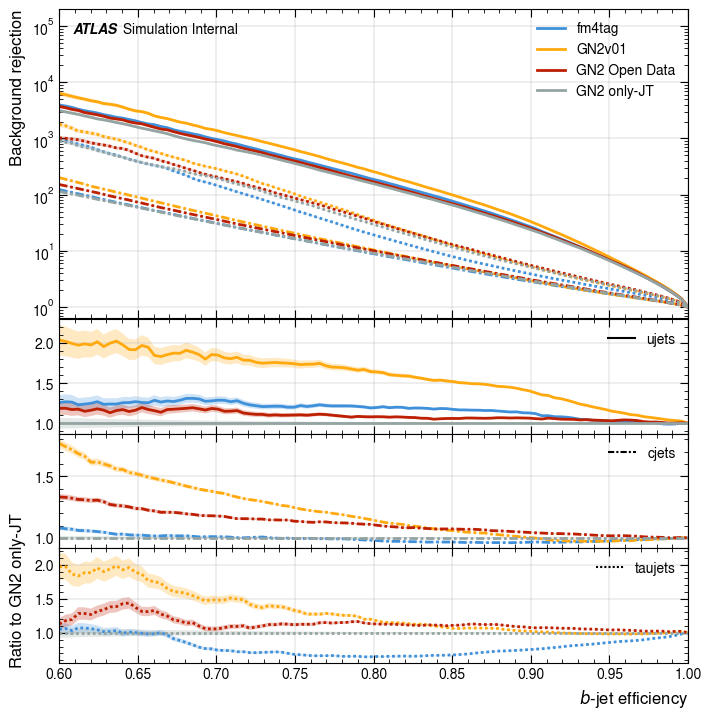

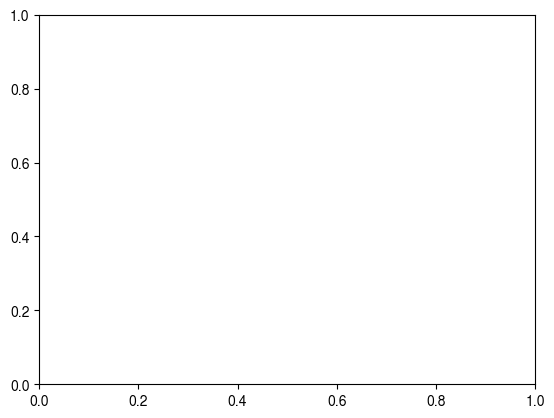

In [15]:
plot_roc = RocPlot(
    n_ratio_panels=3,
    ylabel='Background rejection',
    xlabel='$b$-jet efficiency',
    figsize=(7, 7),
    y_scale=1.3,
)


def _add_triple(label, u_rej, c_rej, tau_rej, n_u, n_c, n_tau, reference=False):
    """Add pre-computed u/c/tau rejection curves for one tagger."""
    for rej, n, cls in [
        (u_rej, n_u, 'ujets'),
        (c_rej, n_c, 'cjets'),
        (tau_rej, n_tau, 'taujets'),
    ]:
        plot_roc.add_roc(
            Roc(
                SIG_EFF, rej, n_test=n, rej_class=cls, signal_class='bjets', label=label
            ),
            reference=reference,
        )


# fm4tag is the reference — its ratio panel will show 1
_add_triple(
    FM4TAG_LABEL,
    fm4tag_u_rej,
    fm4tag_c_rej,
    fm4tag_tau_rej,
    n_fm4tag_u,
    n_fm4tag_c,
    n_fm4tag_tau,
)
_add_triple(
    'GN2v01', gn2v01_u_rej, gn2v01_c_rej, gn2v01_tau_rej, n_ref_u, n_ref_c, n_ref_tau
)
_add_triple(
    'GN2 Open Data',
    gn2od_u_rej,
    gn2od_c_rej,
    gn2od_tau_rej,
    n_ref_u,
    n_ref_c,
    n_ref_tau,
)
_add_triple(
    'GN2 only-JT',
    gn2jt_u_rej,
    gn2jt_c_rej,
    gn2jt_tau_rej,
    n_jt_u,
    n_jt_c,
    n_jt_tau,
    reference=True,
)
# _add_triple('DL1dv01',      dl1d_u_rej,   dl1d_c_rej,    dl1d_tau_rej,    n_ref_u, n_ref_c, n_ref_tau)

plot_roc.set_ratio_class(1, 'ujets', 'ujets')
plot_roc.set_ratio_class(2, 'cjets', 'cjets')
plot_roc.set_ratio_class(3, 'taujets', 'taujets')
plot_roc.draw()
plot_roc.savefig('roc_comparison.png', transparent=False)
plot_roc.show()

In [12]:
help(plot_roc.set_ratio_class)

Help on method set_ratio_class in module puma.roc:

set_ratio_class(
    ratio_panel: 'int',
    rej_class: 'str | Label',
    rej_class_label: 'str | None' = None
) -> 'None' method of puma.roc.RocPlot instance
    Associate the rejection class to a ratio panel adn set the legend label.

    Parameters
    ----------
    ratio_panel : int
        Ratio panel either 1 or 2
    rej_class : str | Label
        Rejection class associated to that panel. Either a Label instance or a string
    rej_class_label : str | None, optional
        If rej_class is not a Label, this label must be given

    Raises
    ------
    TypeError
        If the rej_class is a string and rej_class_label is not defined



## Discriminant score distributions

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

bins = np.linspace(-10, 20, 100)
styles = dict(histtype='step', density=True, bins=bins)

# Left: per-flavour distributions for fm4tag
ax = axes[0]
ax.hist(discs_fm4tag[is_b_fm4tag], **styles, label='b', color='royalblue')
ax.hist(discs_fm4tag[is_c_fm4tag], **styles, label='c', color='darkorange')
ax.hist(discs_fm4tag[is_u_fm4tag], **styles, label='u', color='forestgreen')
ax.hist(discs_fm4tag[is_tau_fm4tag], **styles, label='tau', color='firebrick')
ax.set_xlabel('Discriminant $D_b$')
ax.set_ylabel('Normalised counts')
ax.set_title(f'{FM4TAG_LABEL} — per-flavour')
ax.legend()

# Right: b-jet discriminant comparison across all taggers
ax = axes[1]
ax.hist(discs_fm4tag[is_b_fm4tag], **styles, label=FM4TAG_LABEL)
ax.hist(discs_gn2_v01[is_b], **styles, label='GN2v01')
ax.hist(discs_gn2_od[is_b], **styles, label='GN2 Open Data')
ax.hist(discs_gn2_jt[is_b_jt], **styles, label='GN2 only-JT')
ax.hist(discs_dl1d_v01[is_b], **styles, label='DL1dv01')
ax.set_xlabel('Discriminant $D_b$')
ax.set_ylabel('Normalised counts')
ax.set_title('b-jet discriminant — all taggers')
ax.legend()

plt.tight_layout()
plt.savefig('disc_distributions.png', dpi=150)
plt.show()

## Rejection at fixed working points

Quick table: u-jet and c-jet rejection at $\varepsilon_b = 0.70$ and $\varepsilon_b = 0.77$.

In [ ]:
def rej_at_eff(discs_sig, discs_bkg, target_eff):
    """Background rejection at a target signal efficiency.
    Filters non-finite values (log(0)=-inf, 0/0=nan) before computing the threshold.
    """
    sig_finite = discs_sig[np.isfinite(discs_sig)]
    bkg_finite = discs_bkg[np.isfinite(discs_bkg)]
    threshold = np.quantile(sig_finite, 1 - target_eff)
    n_pass = (bkg_finite > threshold).sum()
    return len(bkg_finite) / n_pass if n_pass > 0 else np.inf


taggers = {
    FM4TAG_LABEL: (discs_fm4tag, is_b_fm4tag, is_u_fm4tag, is_c_fm4tag),
    'GN2v01': (discs_gn2_v01, is_b, is_u, is_c),
    'GN2-OD': (discs_gn2_od, is_b, is_u, is_c),
    'GN2-JT': (discs_gn2_jt, is_b_jt, is_u_jt, is_c_jt),
    'DL1dv01': (discs_dl1d_v01, is_b, is_u, is_c),
}

for wp in [0.70, 0.77]:
    print(f'\n  ε_b = {wp:.0%}')
    print(f'  {"Tagger":<18}  {"u-rej":>8}  {"c-rej":>8}')
    print(f'  {"-" * 18}  {"-" * 8}  {"-" * 8}')
    for name, (d, ib, iu, ic) in taggers.items():
        u_rej = rej_at_eff(d[ib], d[iu], wp)
        c_rej = rej_at_eff(d[ib], d[ic], wp)
        print(f'  {name:<18}  {u_rej:>8.1f}  {c_rej:>8.1f}')